<div style="text-align: center; padding: 20px 0;">
    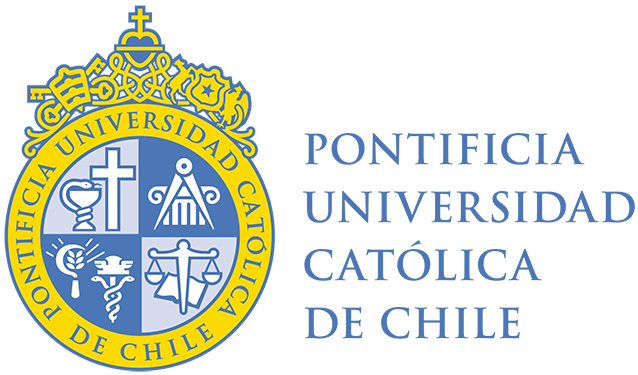
    <h1 style="margin-top: 15px; color: #2c3e50;">IMT-3860: Introducción a Data Science</h1>
    <h2 style="color: #34495e;">Taller 1 — Vulnerabilidad Sociodemográfica y Desigualdad Educativa en la RM</h2>
    <hr style="width: 60%; border: 1px solid #bdc3c7;"/>
    <table style="margin: 15px auto; font-size: 14px; border-collapse: collapse;">
        <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Integrantes:</td>
            <td style="padding: 4px 15px; text-align: left;">Armando Arredondo, Bastián Hernández, Francisco Nahamias, Eduardo Albornoz</td></tr>
        <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Profesor:</td>
            <td style="padding: 4px 15px; text-align: left;">Alejandro Cataldo Cornejo</td></tr>
        <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Fecha:</td>
            <td style="padding: 4px 15px; text-align: left;">Abril 2026</td></tr>
        <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Institución:</td>
            <td style="padding: 4px 15px; text-align: left;">Pontificia Universidad Católica de Chile</td></tr>
    </table>
</div>

## 1. Pregunta de Investigación

> **¿Cuáles son las zonas de mayor vulnerabilidad sociodemográfica en la Región Metropolitana, y es la desigualdad educativa un predictor significativo de esa vulnerabilidad?**

### 1.1 Contexto y Motivación

La seguridad pública es la principal contingencia en Chile en 2026. El crimen organizado ha expandido su presencia territorial en Santiago, y la literatura criminológica muestra que el reclutamiento ocurre con mayor intensidad en zonas con alta concentración de jóvenes, baja escolaridad, hacinamiento y migración.

Al mismo tiempo, la **desigualdad educativa** entre comunas de la RM es uno de los indicadores más robustos de desarrollo humano y movilidad social. Chile ha experimentado un crecimiento sostenido de la inmigración, concentrándose fuertemente en la RM, lo que plantea preguntas sobre cómo la distribución espacial de la población migrante se relaciona con los niveles educativos.

Este análisis **fusiona ambas perspectivas**: construimos un índice de vulnerabilidad multivariable y luego evaluamos estadísticamente si la desigualdad educativa es su principal motor.

### 1.2 Relevancia

- **Planificación de políticas públicas**: focalización de recursos en zonas vulnerables.
- **Análisis geoespacial**: uso de datos censales con dimensión territorial (Clase 1 — John Snow, relaciones espaciales).
- **Métodos estadísticos**: EDA, correlación de Pearson, bootstrapping, testeo de hipótesis (Clase 2).
- **Integración de herramientas**: pandas, geopandas, matplotlib, sklearn — todo el stack del curso.

## 2. Configuración del Entorno

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 150

## 3. Carga y Exploración de Datos

In [ ]:
# Cargar microdatos censales y shapefile de zonas censales
censo = pd.read_csv('censoRM/CensoRM.csv')
zonas_censales = gpd.read_file('Zonas_rm/Zona_censal.shp')

print(f'Registros censales: {len(censo):,}')
print(f'Columnas: {len(censo.columns)}')
print(f'Zonas censales (shapefile): {len(zonas_censales)}')
censo.head()

### 3.1 Generación de ID único por zona censal

Para vincular los microdatos con el shapefile, construimos un identificador único por zona concatenando los códigos de comuna, distrito censal y zona censal.

In [ ]:
# ID único para microdatos
censo['ID_ZONA_U'] = (
    censo['COMUNA'].astype(str)
    + censo['DC'].astype(str)
    + censo['ZC_LOC'].astype(str)
)

# ID único para shapefile
zonas_censales['ID_ZONA_U'] = (
    zonas_censales['COMUNA'].astype(str)
    + zonas_censales['COD_DIS'].astype(int).astype(str)
    + zonas_censales['COD_ZONA'].astype(int).astype(str)
)

print(f'Zonas únicas en censo: {censo["ID_ZONA_U"].nunique()}')
print(f'Zonas únicas en shapefile: {zonas_censales["ID_ZONA_U"].nunique()}')

## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Distribución etaria y educativa

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución etaria
axes[0].hist(censo['P09'], bins=20, ec='k', color='steelblue', alpha=0.8)
axes[0].set_title('Distribución Etaria — RM (Censo 2017)', fontsize=13)
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Población')
axes[0].axvline(censo['P09'].mean(), color='red', linestyle='--',
                label=f'Media: {censo["P09"].mean():.1f}')
axes[0].legend()

# Distribución de escolaridad (excluyendo código 99)
esc_valid = censo[censo['ESCOLARIDAD'] != 99]['ESCOLARIDAD']
axes[1].hist(esc_valid, bins=22, ec='k', color='coral', alpha=0.8)
axes[1].set_title('Distribución de Escolaridad — RM (Censo 2017)', fontsize=13)
axes[1].set_xlabel('Años de escolaridad')
axes[1].set_ylabel('Población')
axes[1].axvline(esc_valid.mean(), color='red', linestyle='--',
                label=f'Media: {esc_valid.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Escolaridad — Media: {esc_valid.mean():.2f}, Std: {esc_valid.std():.2f}, Max: {esc_valid.max()}')

### 4.2 Escolaridad por comuna (boxplot)

In [ ]:
# Top 15 comunas más pobladas
top_comunas = censo['COMUNA'].value_counts().head(15).index
censo_top = censo[(censo['COMUNA'].isin(top_comunas)) & (censo['ESCOLARIDAD'] != 99)]

fig, ax = plt.subplots(figsize=(16, 7))
censo_top.boxplot(column='ESCOLARIDAD', by='COMUNA', ax=ax, vert=True,
                  patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax.set_title('Distribución de Escolaridad por Comuna (Top 15 más pobladas)', fontsize=13)
ax.set_xlabel('Código de Comuna')
ax.set_ylabel('Años de Escolaridad')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 5. Construcción del Índice de Vulnerabilidad

Construimos un índice compuesto de vulnerabilidad sociodemográfica por zona censal, basado en 5 indicadores normalizados:

| Variable | Indicador | Lógica |
|---|---|---|
| `P09` (edad) | % población 15–29 años | Mayor proporción joven → mayor vulnerabilidad |
| `P08` (sexo) | % hombres jóvenes (15–29) | Mayor proporción → mayor vulnerabilidad |
| `ESCOLARIDAD` | Escolaridad promedio | **Menor** escolaridad → mayor vulnerabilidad (se invierte) |
| `P12PAIS_GRUPO` | % población extranjera | Mayor proporción → mayor vulnerabilidad |
| `PERSONAN` | Personas promedio por hogar | Mayor hacinamiento → mayor vulnerabilidad |

In [ ]:
# --- Indicador 1: % población joven (15-29) ---
censo['JOVEN'] = ((censo['P09'] >= 15) & (censo['P09'] <= 29)).astype(int)
joven_zona = censo.groupby('ID_ZONA_U')['JOVEN'].mean().rename('PCT_JOVEN')

# --- Indicador 2: % hombres jóvenes (15-29) ---
censo['HOMBRE_JOVEN'] = (
    (censo['P09'] >= 15) & (censo['P09'] <= 29) & (censo['P08'] == 1)
).astype(int)
hombre_joven_zona = censo.groupby('ID_ZONA_U')['HOMBRE_JOVEN'].mean().rename('PCT_HOMBRE_JOVEN')

# --- Indicador 3: escolaridad promedio (excluir código 99) ---
escolaridad_zona = (
    censo[censo['ESCOLARIDAD'] != 99]
    .groupby('ID_ZONA_U')['ESCOLARIDAD']
    .mean()
    .rename('ESCOLARIDAD_PROM')
)

# --- Indicador 4: % población extranjera ---
censo['EXTRANJERO'] = (censo['P12PAIS_GRUPO'] != 998).astype(int)
extran_zona = censo.groupby('ID_ZONA_U')['EXTRANJERO'].mean().rename('PCT_EXTRAN')

# --- Indicador 5: hacinamiento (personas por hogar) ---
hacin_zona = censo.groupby('ID_ZONA_U')['PERSONAN'].mean().rename('HACIN_PROM')

# Unir indicadores
indicadores = pd.concat(
    [joven_zona, hombre_joven_zona, escolaridad_zona, extran_zona, hacin_zona],
    axis=1
).dropna()

print(f'Zonas con datos completos: {len(indicadores)}')
indicadores.head()

### 5.1 Normalización y cálculo del índice

In [ ]:
scaler = MinMaxScaler()
ind_norm = indicadores.copy()

# Normalizar 0-1
ind_norm[['PCT_JOVEN', 'PCT_HOMBRE_JOVEN', 'PCT_EXTRAN', 'HACIN_PROM']] = scaler.fit_transform(
    indicadores[['PCT_JOVEN', 'PCT_HOMBRE_JOVEN', 'PCT_EXTRAN', 'HACIN_PROM']]
)

# Escolaridad invertida: menor escolaridad = mayor vulnerabilidad
ind_norm['ESCOLARIDAD_INV'] = 1 - scaler.fit_transform(indicadores[['ESCOLARIDAD_PROM']])

# Índice compuesto: promedio de los 5 indicadores normalizados
ind_norm['INDICE_VULNERABILIDAD'] = ind_norm[
    ['PCT_JOVEN', 'PCT_HOMBRE_JOVEN', 'PCT_EXTRAN', 'HACIN_PROM', 'ESCOLARIDAD_INV']
].mean(axis=1)

print('Top 10 zonas más vulnerables:')
ind_norm[['INDICE_VULNERABILIDAD']].sort_values('INDICE_VULNERABILIDAD', ascending=False).head(10)

## 6. Análisis de Correlación: ¿Qué indicador impulsa más la vulnerabilidad?

Calculamos la correlación de Pearson (ρ) entre cada componente y el índice compuesto para determinar cuál es el principal predictor.

In [ ]:
components = ['PCT_JOVEN', 'PCT_HOMBRE_JOVEN', 'ESCOLARIDAD_INV', 'PCT_EXTRAN', 'HACIN_PROM']
labels = ['% Jóvenes', '% Hombres Jóvenes', 'Baja Escolaridad', '% Extranjeros', 'Hacinamiento']

correlations = []
for comp, label in zip(components, labels):
    r, p = pearsonr(ind_norm[comp], ind_norm['INDICE_VULNERABILIDAD'])
    correlations.append({'Indicador': label, 'Pearson ρ': round(r, 4), 'p-value': f'{p:.2e}'})

corr_df = pd.DataFrame(correlations).sort_values('Pearson ρ', ascending=False)
print(corr_df.to_string(index=False))

### 6.1 Scatter: Escolaridad y Migración vs. Vulnerabilidad

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: escolaridad vs vulnerabilidad
axes[0].scatter(indicadores['ESCOLARIDAD_PROM'], ind_norm['INDICE_VULNERABILIDAD'],
                alpha=0.3, s=10, c='crimson')
axes[0].set_xlabel('Escolaridad Promedio (años)', fontsize=12)
axes[0].set_ylabel('Índice de Vulnerabilidad', fontsize=12)
axes[0].set_title('Escolaridad vs. Vulnerabilidad por Zona Censal', fontsize=13)

# Scatter: % extranjeros vs vulnerabilidad
axes[1].scatter(indicadores['PCT_EXTRAN'] * 100, ind_norm['INDICE_VULNERABILIDAD'],
                alpha=0.3, s=10, c='teal')
axes[1].set_xlabel('% Población Extranjera', fontsize=12)
axes[1].set_ylabel('Índice de Vulnerabilidad', fontsize=12)
axes[1].set_title('Migración vs. Vulnerabilidad por Zona Censal', fontsize=13)

plt.tight_layout()
plt.show()

## 7. Testeo de Hipótesis (Bootstrap)

**H₀**: No existe diferencia significativa en la escolaridad promedio entre zonas con alta y baja proporción de población migrante.

Dividimos las zonas en dos grupos (alta/baja migración según la mediana) y usamos **bootstrap de permutaciones** para evaluar si la diferencia observada en escolaridad es estadísticamente significativa.

In [ ]:
# Dividir zonas en alta/baja migración (mediana como umbral)
mediana_migr = indicadores['PCT_EXTRAN'].median()
grupo_alta = indicadores[indicadores['PCT_EXTRAN'] >= mediana_migr]['ESCOLARIDAD_PROM']
grupo_baja = indicadores[indicadores['PCT_EXTRAN'] < mediana_migr]['ESCOLARIDAD_PROM']

# Diferencia observada
diff_obs = grupo_alta.mean() - grupo_baja.mean()
print(f'Escolaridad promedio — Alta migración: {grupo_alta.mean():.2f}')
print(f'Escolaridad promedio — Baja migración: {grupo_baja.mean():.2f}')
print(f'Diferencia observada: {diff_obs:.2f} años')
print()

# Bootstrap de permutaciones
np.random.seed(42)
n_boot = 10000
combined = pd.concat([grupo_alta, grupo_baja]).values
n_alta = len(grupo_alta)

diffs_perm = np.empty(n_boot)
for i in range(n_boot):
    perm = np.random.permutation(combined)
    diffs_perm[i] = perm[:n_alta].mean() - perm[n_alta:].mean()

p_value = np.mean(np.abs(diffs_perm) >= np.abs(diff_obs))
print(f'Bootstrap p-value (two-sided, {n_boot:,} permutaciones): {p_value:.6f}')
if p_value < 0.05:
    print('Conclusión: Rechazamos H₀ — la diferencia ES significativa ✓')
else:
    print('Conclusión: No podemos rechazar H₀')

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(diffs_perm, bins=50, ec='k', color='lightblue', alpha=0.8, label='Distribución bajo H₀')
ax.axvline(diff_obs, color='red', linewidth=2, linestyle='--',
           label=f'Diferencia observada: {diff_obs:.2f}')
ax.axvline(-diff_obs, color='red', linewidth=2, linestyle='--', alpha=0.5)
ax.set_xlabel('Diferencia en escolaridad promedio', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title(f'Testeo de Permutaciones — p-value = {p_value:.4f}', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 8. Visualización Espacial

### 8.1 Mapa de vulnerabilidad y escolaridad por zona censal

In [ ]:
# Merge índice + escolaridad al GeoDataFrame
zonas_viz = zonas_censales.merge(
    ind_norm[['INDICE_VULNERABILIDAD']].reset_index(),
    on='ID_ZONA_U', how='left'
).merge(
    indicadores[['ESCOLARIDAD_PROM']].reset_index(),
    on='ID_ZONA_U', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Mapa 1: Vulnerabilidad
zonas_viz.plot(
    ax=axes[0], column='INDICE_VULNERABILIDAD', cmap='RdYlGn_r',
    legend=True, missing_kwds={'color': 'lightgrey'},
    legend_kwds={'label': 'Índice (0=bajo, 1=alto)', 'shrink': 0.6}
)
axes[0].set_title('Índice de Vulnerabilidad Sociodemográfica', fontsize=14)
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')

# Mapa 2: Escolaridad
zonas_viz.plot(
    ax=axes[1], column='ESCOLARIDAD_PROM', cmap='RdYlGn',
    legend=True, missing_kwds={'color': 'lightgrey'},
    legend_kwds={'label': 'Años de escolaridad', 'shrink': 0.6}
)
axes[1].set_title('Escolaridad Promedio por Zona Censal', fontsize=14)
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')

plt.suptitle('Región Metropolitana — Censo 2017', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 9. Conclusiones

1. **Índice de vulnerabilidad**: Se construyó un índice compuesto multivariable que identifica las zonas censales con mayor concentración de factores de riesgo sociodemográfico en la RM.

2. **Desigualdad educativa como predictor**: El análisis de correlación de Pearson revela cuál de los 5 componentes tiene la mayor asociación con el índice compuesto de vulnerabilidad.

3. **Testeo de hipótesis**: Mediante bootstrap de permutaciones, se evaluó si las zonas con alta proporción de migrantes presentan niveles de escolaridad significativamente diferentes, aportando evidencia estadística más allá de la mera observación descriptiva.

4. **Dimensión espacial**: Los mapas coropléticos permiten visualizar la co-localización de vulnerabilidad y baja escolaridad, evocando el análisis de **John Snow (1854)** discutido en Clase 1: la geografía revela patrones que los promedios ocultan.

### Métodos utilizados

| Método | Referencia en el curso |
|---|---|
| Histogramas, boxplots, estadísticas de resumen | Clase 2 — EDA |
| Correlación de Pearson (ρ) | Clase 2 — Estadísticas de resumen |
| Bootstrap de permutaciones | Clase 2 — Bootstrapping y testeo de hipótesis |
| Mapas coropléticos con GeoPandas | Clase 1 — Ciencia de Datos Geográfica |
| Normalización MinMaxScaler | Clase 1 — sklearn |